## Plot gifs for weather data

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import math
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
from matplotlib import rcParams
import matplotlib
from datetime import date, timedelta, datetime

In [2]:
rcParams['font.size'] = 20

In [3]:
#output file location
output_write = '/div/nac/users/zofias/XXN/extreme_loc_tables'
out_plots = '/div/nac/users/zofias/plots/XXN/gif_plots'
input_fileloc = '/div/no-backup-nac/users/zofias/CESM2-LENS/weather_data/westNO_events_05_05'

group_label = 'WestNO_events_04_05_26'
plot_title = 'West NO'

var_name='PRECT'

sigma_lab = 5

# %%
# select region by changing region_label
region_label = 'NO_ext' #sys.argv[3] #'EU' # 'SA' 'EA' 'NA' 'EU'

regions = {'SA': [5,35,65,95],
           'EA' : [20,53,95,133],
           'NA' : [25,70,-150,-45],
           'EU' : [35,70,-20,45],
           'NO' : [53,72,0,32],
           'NO_ext': [45,80,-25,37]}

#selects lat lon bounds for region (including for plotting boundaries)
lat_min, lat_max, lon_min, lon_max = regions[region_label]


In [4]:
#csv with selected event details
locs_dataframe = pd.read_csv(f'/div/nac/users/zofias/XXN/extreme_loc_tables/{group_label}_table.csv',index_col=0)

In [5]:
locs_dataframe

,img_filename,ens_member,date,member_ind,lat,lon,year,member_lab,decade_lab
0,PRECT5day_5_r24_2076-07-18_62.67_6.25_single.png,r24,2076-07-18,23,62.67,6.25,2076,1251.014,20750101-20841231.nc
1,PRECT5day_5_r30_2020-05-12_61.73_6.25_single.png,r30,2020-05-12,29,61.73,6.25,2020,1251.020,20150101-20241231.nc
2,PRECT5day_5_r49_2049-12-07_61.73_6.25_single.png,r49,2049-12-07,48,61.73,6.25,2049,1301.019,20450101-20541231.nc
3,PRECT5day_5_r36_2096-06-12_62.67_6.25_single.png,r36,2096-06-12,35,62.67,6.25,2096,1281.016,20950101-21001231.nc
4,PRECT5day_5_r31_2093-11-19_62.04_6.25_single.png,r31,2093-11-19,30,62.04,6.25,2093,1281.011,20850101-20941231.nc


In [6]:
#for plotting
ncols = 3 #set number of columns for subplots
nrows = math.ceil((locs_dataframe.shape[0]/ncols)) #set number of rows for subplots

In [7]:
#make dictionary of dataframes loaded in - single files for each location
datasets = {}

for a, b in enumerate(locs_dataframe.index):
    print(f'Processing {a+1} of {len(locs_dataframe.index)}')

    #get event date from table
    print(f'Event on {locs_dataframe["date"][a]}')
    event_datetime = datetime.strptime(locs_dataframe["date"][a], "%Y-%m-%d")

    #import 15days before and 4 days after event date 
    start_date = (event_datetime - timedelta(days=15)).strftime("%Y-%m-%d")
    end_date = (event_datetime + timedelta(days=4)).strftime("%Y-%m-%d")
    event_date = event_datetime.strftime("%Y-%m-%d")

    #import data
    import_data = xr.open_mfdataset(f"{input_fileloc}/*{locs_dataframe['member_lab'][a]}*{locs_dataframe['decade_lab'][a]}", decode_times=True).sel(time=slice(start_date,end_date))#.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
    #reset lon coord
    import_data = import_data.assign_coords(lon=(((import_data.lon + 180) % 360) - 180)).sortby('lon')
    import_data = import_data.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
    #add to dictionary
    datasets[a] = import_data

Processing 1 of 5
Event on 2076-07-18
Processing 2 of 5
Event on 2020-05-12
Processing 3 of 5
Event on 2049-12-07
Processing 4 of 5
Event on 2096-06-12
Processing 5 of 5
Event on 2093-11-19


### Plot precip on event day

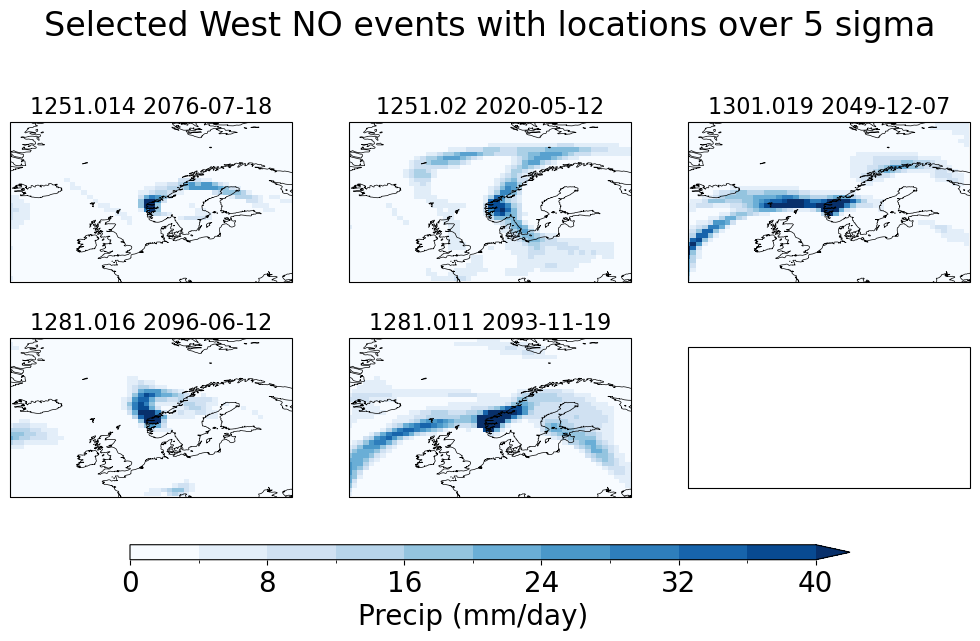

In [ ]:
# Define the figure and each axis for the 3 rows and 3 columns
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(12,5*nrows)
                       )

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()#Loop over all of the models

for n,time in enumerate(locs_dataframe.date):
    member_lab = locs_dataframe.member_lab[n]
    #exp_lab = locs_dataframe.exp[n]
    #suite_lab= locs_dataframe.suiteid[n]
    #lon_lab=events_array.lon[n]

    #circle2 = plt.Circle((lon_lab, lat_lab), 2, color='blue', fill=False)

    fg = (datasets[n][var_name]*8.64e7).sel(time=time).plot(ax=axs[n],cmap='Blues',add_colorbar=False,levels=11,#,norm=norm, #
                                                vmax=40, vmin=0, 
        #cbar_kwargs={'label': f'Temperature (K)','orientation':'horizontal','pad':0.05},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    
    #axs[n].add_patch(circle2)
    axs[n].set_title(f'{member_lab} {time}',fontsize=16)
    axs[n].coastlines(linewidth=0.5)  # cartopy function

cbar_ax = fig.add_axes([0.2, 0.45, 0.6, 0.015])
cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Precip (mm/day)')

plt.suptitle(f'Selected {plot_title} events with locations over {sigma_lab} sigma',y=1.0)
fig.subplots_adjust(bottom=0.5, top=0.9, left=0.1, right=0.9,wspace=0.2, hspace=0.17)
#fig.savefig(f'{out_plots}{region_label}_select_events_precip_maps.pdf', format='pdf', bbox_inches='tight')

## Plot precip evolution for all events

In [8]:
#extract lats and lons for quiver plots
lats=datasets[0].lat
lons=datasets[0].lon

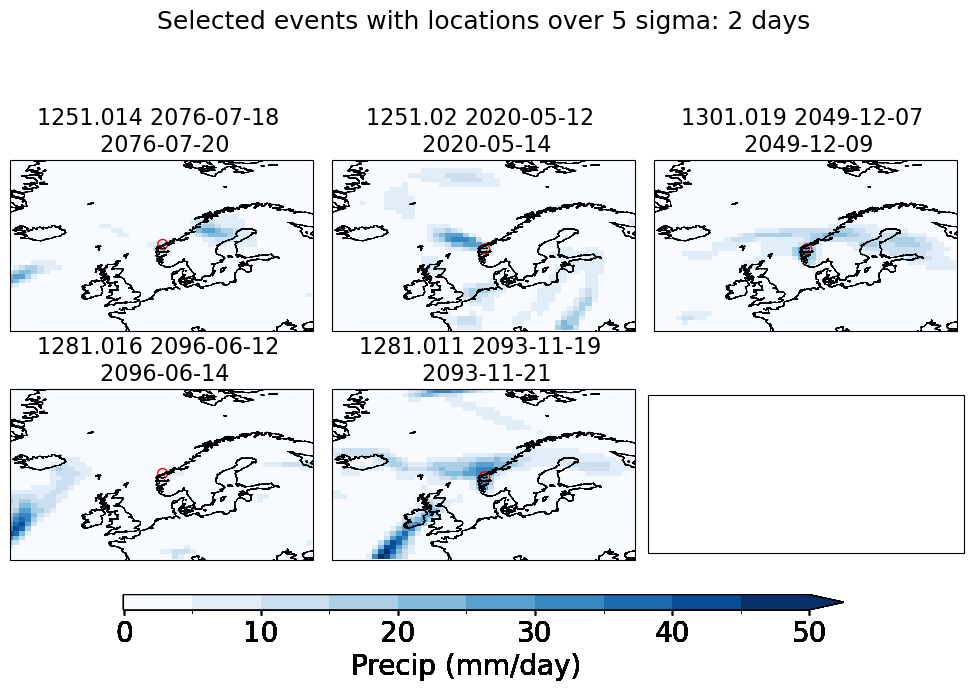

In [ ]:
# Precip maps for all events, from 14 days before up to event
# Define the figure and each axis for the 3 rows and 3 columns
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(12,5*nrows)
                       )

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()
#loop over 15 times
for index,day in enumerate(range(-15,3)):
    #Loop over all of the models
    for n,time in enumerate(locs_dataframe.date):
        member_lab = locs_dataframe.member_lab[n]
        lon_lab = locs_dataframe.lon[n]
        lat_lab= locs_dataframe.lat[n]
        time_ind = np.where(datasets[n].time == datasets[n].sel(time=time).time.item())[0][0]
        
        
        fg = (datasets[n][var_name]*8.64e7).isel(time=time_ind+day).plot(ax=axs[n],
                                                             cmap='Blues',
                                                             levels=11,
                                                             add_colorbar=False,
                                                             vmax=50, vmin=0,
                                                             xlim=(lon_min,lon_max),
                                                             ylim=(lat_min,lat_max),
                                                              )
    
        #axs[n].add_patch(circle2)
        axs[n].set_title(f"{member_lab} {time} \n {datasets[n].time.dt.strftime('%Y-%m-%d').isel(time=time_ind+day).item()}",fontsize=16)
        axs[n].coastlines(linewidth=0.5)  # cartopy function
        circle2 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)
        axs[n].add_patch(circle2)
    
    cbar_ax = fig.add_axes([0.2, 0.45, 0.6, 0.015])
    cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Precip (mm/day)',extend='max')
    plt.suptitle(f'Selected events with locations over {sigma_lab} sigma: {day} days',y=1.05,fontsize=18)
    fig.subplots_adjust(bottom=0.5, top=0.9, left=0.1, right=0.9,wspace=0.02, hspace=0.34)
    fig.savefig(f'{out_plots}/{str(index).zfill(2)}_{region_label}_select_events_{group_label}_precip_maps.png', format='png', bbox_inches='tight')

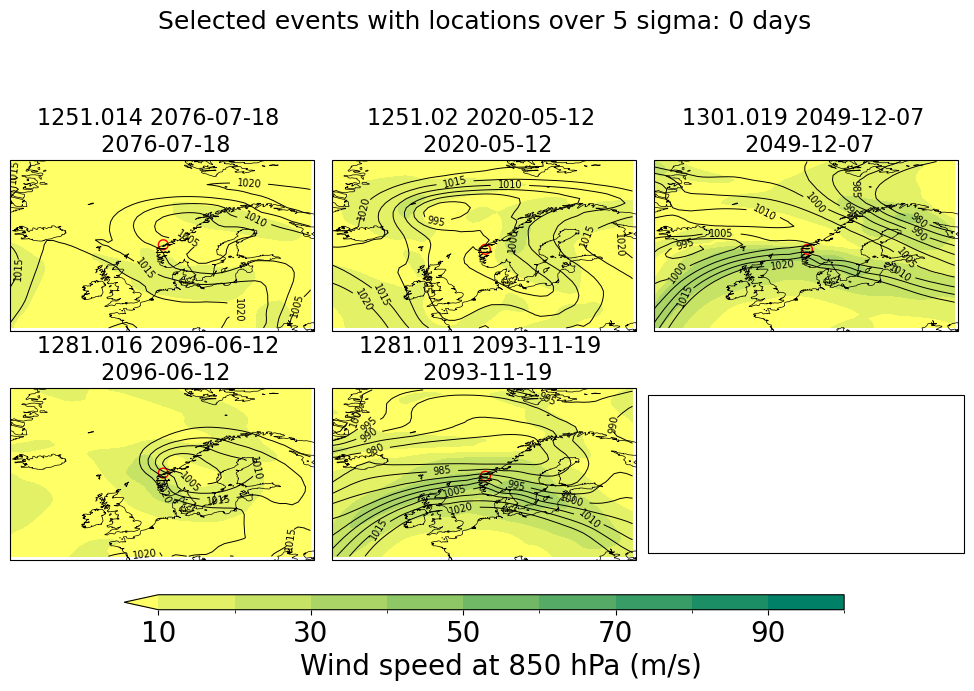

In [10]:
# PSL map with wind speed contours for all events (event day)
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(12,5*nrows)
                       )

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()
#loop over 15 times
for index,day in enumerate(range(1)):
    #Loop over all of the models
    for n,time in enumerate(locs_dataframe.date):
        member_lab = locs_dataframe.member_lab[n]
        lon_lab = locs_dataframe.lon[n]
        lat_lab= locs_dataframe.lat[n]
        time_ind = np.where(datasets[n].time == datasets[n].sel(time=time).time.item())[0][0]

        u = datasets[n].isel(time=time_ind+day).U850
        v = datasets[n].isel(time=time_ind+day).V850

        wind_speed = np.sqrt(u**2 + v**2)
        
        axs[n].clear()
        fg = (datasets[n]['PSL'].sel(lon=slice(lon_min-1,lon_max+1),lat=slice(lat_min-1,lat_max+1)).isel(time=time_ind+day)/100).plot.contour(ax=axs[n],
                                                             #cmap='viridis',
                                                             #add_colorbar=False,
                                                             vmax=1020, vmin=980,
                                                             levels=9,#
                                                             xlim=(lon_min,lon_max),
                                                             ylim=(lat_min,lat_max),
                                                             colors='k',
                                                             linewidths=0.7
                                                             )
        fg2 = wind_speed.plot.contourf(ax=axs[n],cmap='summer_r',levels=10,add_colorbar=False, vmin=10,vmax=100) #,norm=norm, #
    
        #axs[n].add_patch(circle2)
        axs[n].set_title(f"{member_lab} {time} \n {datasets[n].time.dt.strftime('%Y-%m-%d').isel(time=time_ind+day).item()}",fontsize=16)
        axs[n].coastlines(linewidth=0.5)  # cartopy function
        circle2 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)
        axs[n].add_patch(circle2)
        axs[n].clabel(fg,fontsize=7)

    cbar_ax = fig.add_axes([0.2, 0.45, 0.6, 0.015])
    cbar=fig.colorbar(fg2,cax=cbar_ax,orientation='horizontal',label='Wind speed at 850 hPa (m/s)',extend='both',ticks=np.arange(10, 101, 20))

    plt.suptitle(f'Selected events with locations over {sigma_lab} sigma: {day} days',y=1.05,fontsize=18)
    fig.subplots_adjust(bottom=0.5, top=0.9, left=0.1, right=0.9,wspace=0.02, hspace=0.33)
    fig.savefig(f'{out_plots}/{str(index).zfill(2)}_{region_label}_select_events_PSL_{group_label}_maps.png', format='png', bbox_inches='tight')
    #plt.clf()

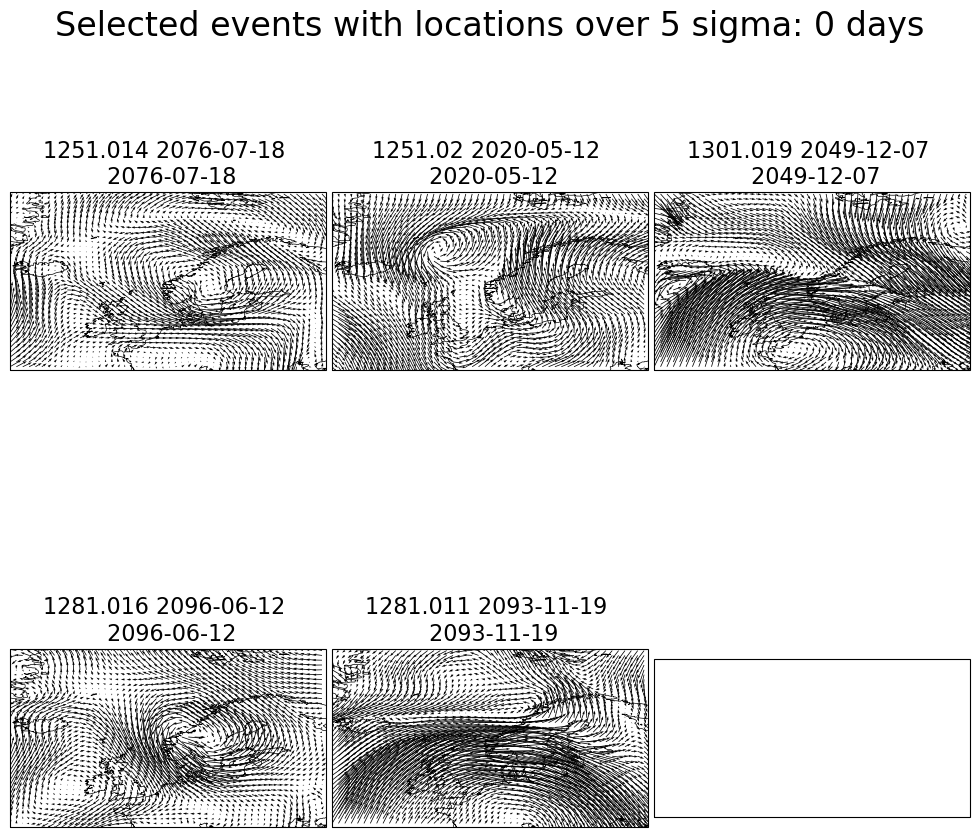

In [20]:
#quiver plots, currently only plotting event day
#loop over 15 times
for index,day in enumerate(range(1)): #-15,3
    fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(12,10*nrows)
                       )

     # axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
    axs=axs.flatten()

    #Loop over all of the models
    for n,time in enumerate(locs_dataframe.date):
        member_lab = locs_dataframe.member_lab[n]
        lon_lab = locs_dataframe.lon[n]
        lat_lab= locs_dataframe.lat[n]
        time_ind = np.where(datasets[n].time == datasets[n].sel(time=time).time.item())[0][0]

        u = datasets[n].isel(time=time_ind+day).U850.squeeze()
        v = datasets[n].isel(time=time_ind+day).V850.squeeze()

        fg = axs[n].quiver(lons, lats, u, v, scale=250) #change scale to change size of arrows

        #axs[n].add_patch(circle2)
        axs[n].set_title(f"{member_lab} {time} \n {datasets[n].time.dt.strftime('%Y-%m-%d').isel(time=time_ind+day).item()}",fontsize=16)
        axs[n].coastlines(linewidth=0.5)  # cartopy function
        axs[n].set_xlim(lon_min,lon_max)
        axs[n].set_ylim(lat_min,lat_max)

    plt.suptitle(f'Selected events with locations over {sigma_lab} sigma: {day} days',y=0.95)
    fig.subplots_adjust(bottom=0.5, top=0.9, left=0.1, right=0.9,wspace=0.02, hspace=0.33)
    #fig.savefig(f'{out_plots}/{str(index).zfill(2)}_{region_label}_{group_label}_quiver_maps.png', format='png', bbox_inches='tight')
    #plt.close()

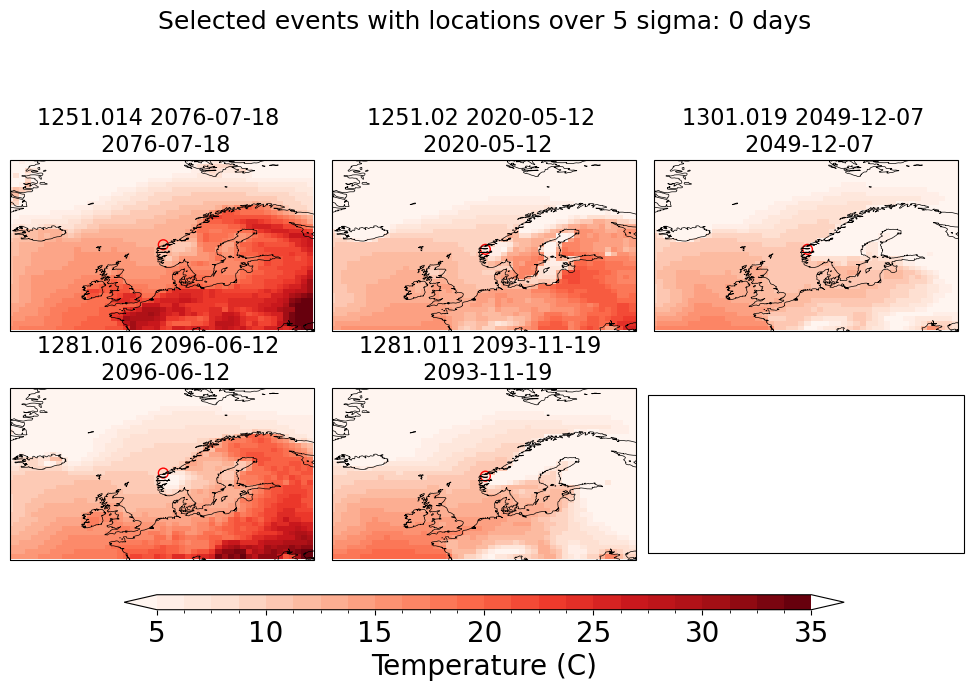

In [16]:
#temp plot, day of event 
# Define the figure and each axis for the 3 rows and 3 columns
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(12,5*nrows)
                       )

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()
#loop over 15 times
for index,day in enumerate(range(1)): #-15,3
    #Loop over all of the models
    for n,time in enumerate(locs_dataframe.date):
        member_lab = locs_dataframe.member_lab[n]
        lon_lab = locs_dataframe.lon[n]
        lat_lab= locs_dataframe.lat[n]
        time_ind = np.where(datasets[n].time == datasets[n].sel(time=time).time.item())[0][0]
        
        axs[n].clear()
        fg = (datasets[n]['TS'].isel(time=time_ind+day)-273.15).plot(ax=axs[n],
                                                             cmap='Reds',
                                                             add_colorbar=False,
                                                             vmax=35, vmin=5,
                                                             levels=25,#
                                                             xlim=(lon_min,lon_max),
                                                             ylim=(lat_min,lat_max),
                                                              )
    
        #axs[n].add_patch(circle2)
        axs[n].set_title(f"{member_lab} {time} \n {datasets[n].time.dt.strftime('%Y-%m-%d').isel(time=time_ind+day).item()}",fontsize=16)
        axs[n].coastlines(linewidth=0.5)  # cartopy function
        circle2 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)
        axs[n].add_patch(circle2)

    cbar_ax = fig.add_axes([0.2, 0.45, 0.6, 0.015])
    cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Temperature (C)',extend='both',ticks=np.arange(5, 36, 5))

    plt.suptitle(f'Selected events with locations over {sigma_lab} sigma: {day} days',y=1.05,fontsize=18)
    fig.subplots_adjust(bottom=0.5, top=0.9, left=0.1, right=0.9,wspace=0.02, hspace=0.33)
    #fig.savefig(f'{out_plots}/{str(index).zfill(2)}_{region_label}_select_events_TS_{group_label}_maps.png', format='png', bbox_inches='tight')
    #plt.clf()

### Plots per event - precip, temp, PSL, and wind

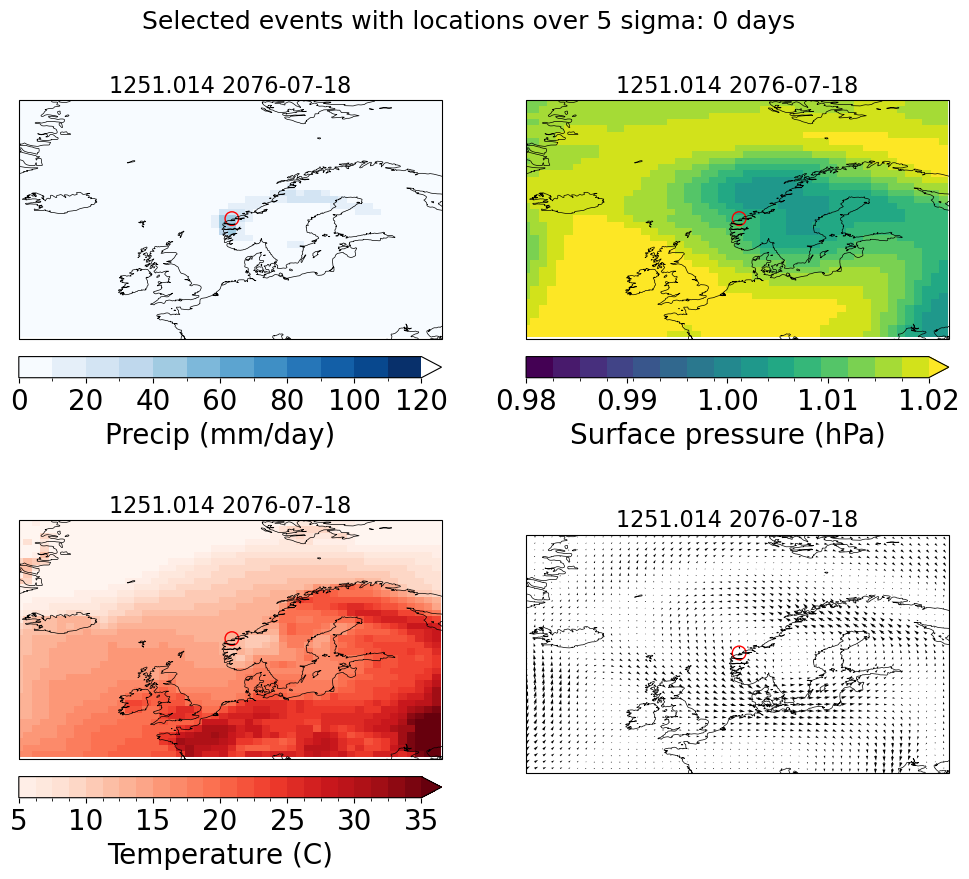

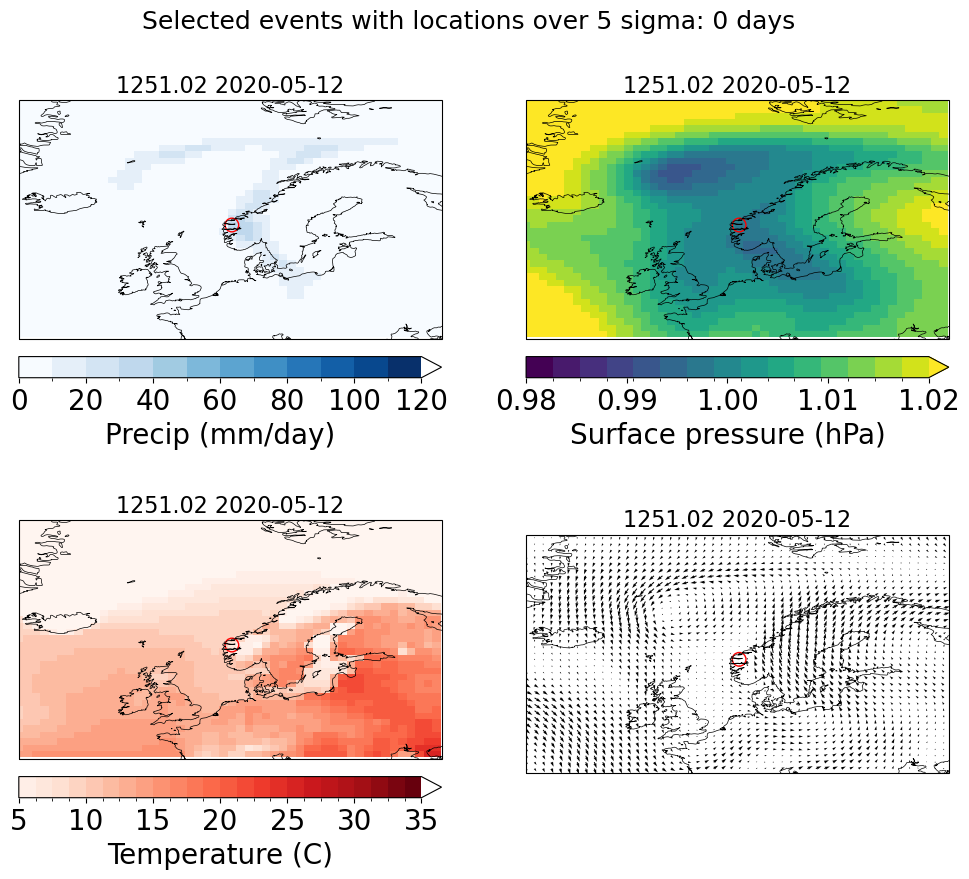

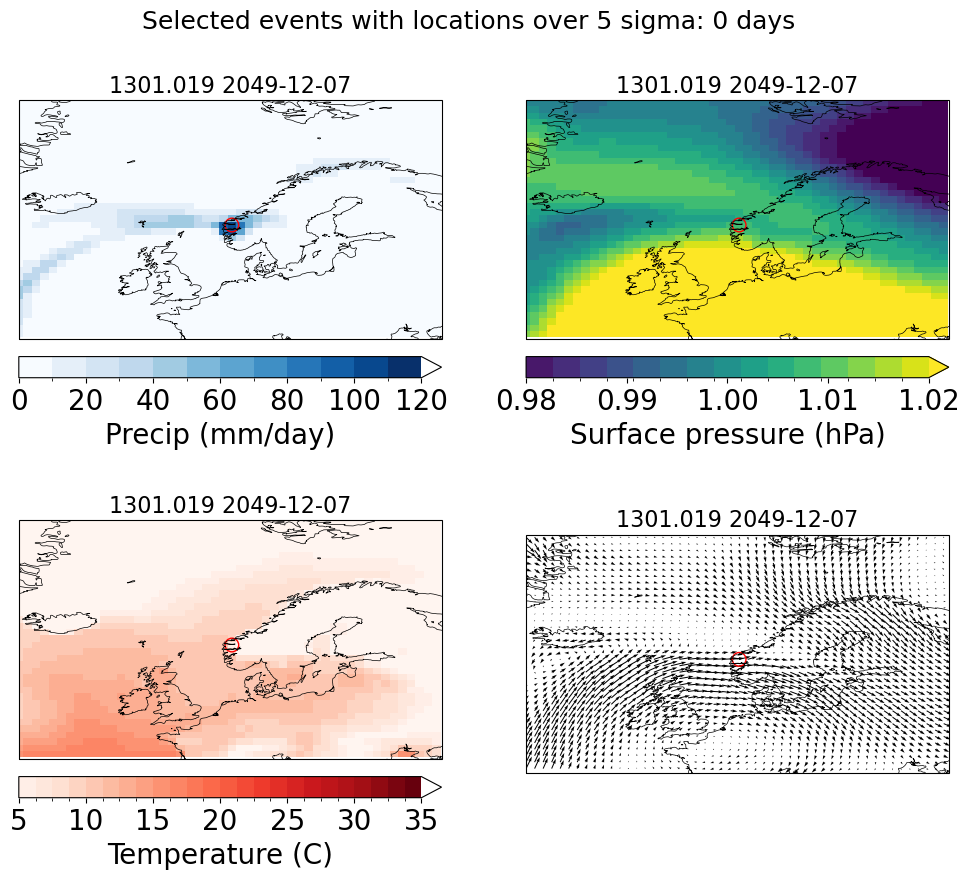

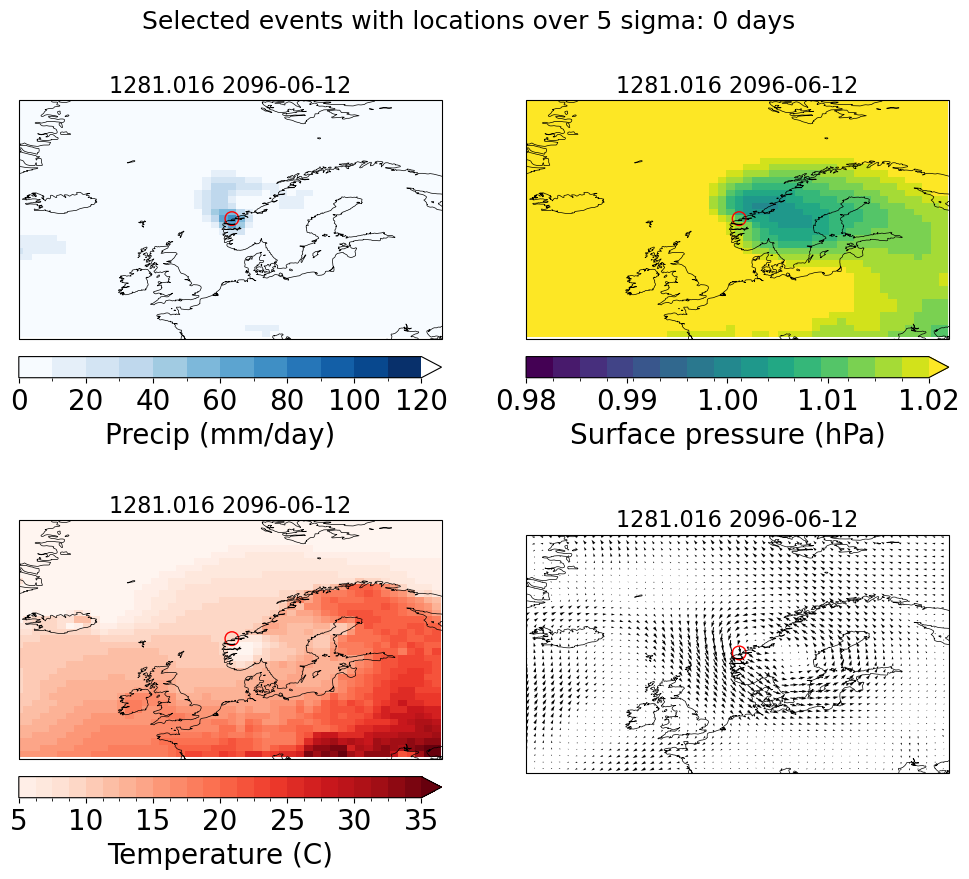

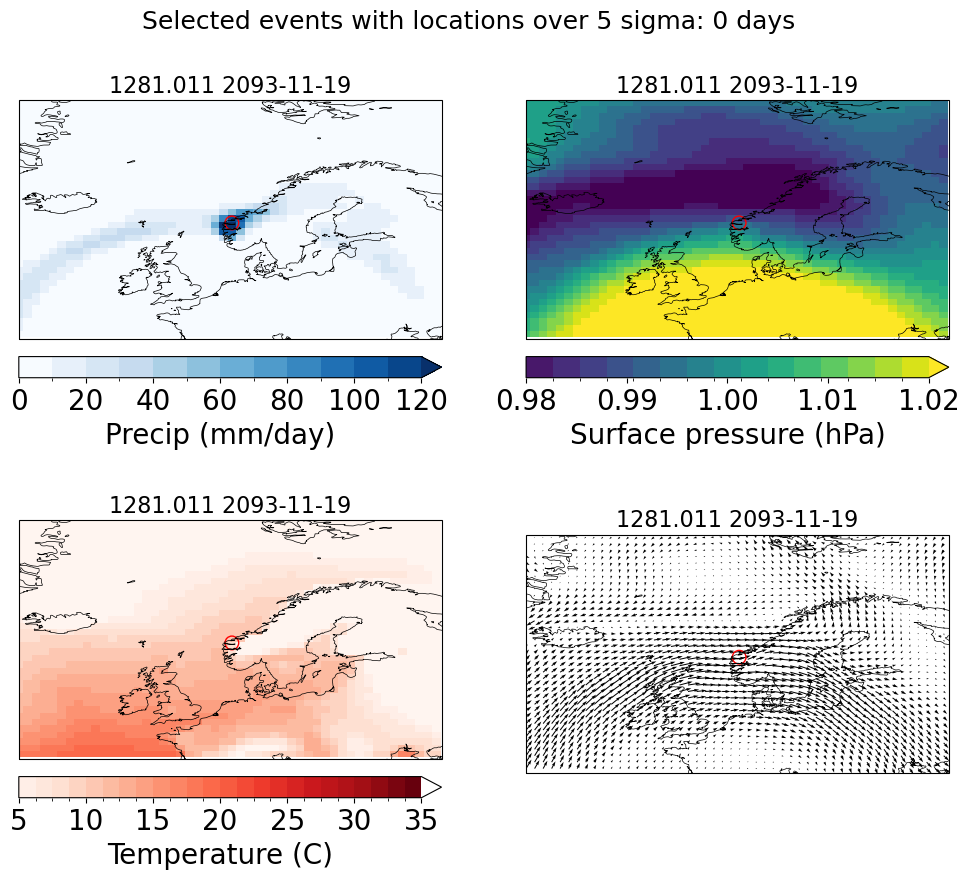

In [18]:
#test 4 panel plot (precip, PSL, TS, and wind) for each event date
for n,time in enumerate(locs_dataframe.date):
    # Define the figure and each axis for the 3 rows and 3 columns
    fig, axs = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(12,10)
                       )
    # axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
    axs=axs.flatten()#Loop over all of the models

    
    member_lab = locs_dataframe.member_lab[n]
    lon_lab = locs_dataframe.lon[n]
    lat_lab= locs_dataframe.lat[n]

    circle0 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)
    circle1 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)
    circle2 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)
    circle3 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)

    fg = (datasets[n][var_name]*8.64e7).sel(time=time).plot(ax=axs[0],cmap='Blues',levels=13,#,norm=norm, #
                                                vmax=120, vmin=0, 
        cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05,'extend':'max'},
        xlim=(lon_min,lon_max),
        ylim=(lat_min,lat_max),
        )
    axs[0].set_title(f'{member_lab} {time}',fontsize=16)
    axs[0].coastlines(linewidth=0.5)  # cartopy function
    axs[0].add_patch(circle0)

    
    fg = (datasets[n]['PSL'].sel(time=time)/1e5).plot(ax=axs[1],
                                                             cmap='viridis',
                                                             cbar_kwargs={'label': f'Surface pressure (hPa)','extend':'both','ticks': np.arange(0.98, 1.03, 0.01),'orientation':'horizontal','pad':0.05,'extend':'max'},
                                                             vmax=1.02, vmin=0.98,
                                                             levels=16,#
                                                             xlim=(lon_min,lon_max),
                                                             ylim=(lat_min,lat_max),
                                                              )
    
    axs[1].set_title(f'{member_lab} {time}',fontsize=16)
    axs[1].coastlines(linewidth=0.5)  # cartopy function
    axs[1].add_patch(circle1)


    fg = (datasets[n]['TS'].sel(time=time)-273.15).plot(ax=axs[2],
                                                             cmap='Reds',
                                                             vmax=35, vmin=5,
                                                             levels=25,#
                                                             xlim=(lon_min,lon_max),
                                                             ylim=(lat_min,lat_max),
                                                             cbar_kwargs={'label': f'Temperature (C)','extend':'both','ticks': np.arange(5, 36, 5),'orientation':'horizontal','pad':0.05,'extend':'max'},
                                                              )
    
    #axs[n].add_patch(circle2)
    axs[2].set_title(f"{member_lab} {time}",fontsize=16)
    axs[2].coastlines(linewidth=0.5)  # cartopy function
    axs[2].add_patch(circle2)

    
    

    u = datasets[n].sel(time=time).U850.squeeze()
    v = datasets[n].sel(time=time).V850.squeeze()

    fg = axs[3].quiver(lons, lats, u, v, scale=1000)

    axs[3].set_title(f"{member_lab} {time}",fontsize=16)
    axs[3].coastlines(linewidth=0.5)  # cartopy function
    axs[3].set_xlim(lon_min,lon_max)
    axs[3].set_ylim(lat_min,lat_max)
    axs[3].add_patch(circle3)

    plt.suptitle(f'Selected events with locations over {sigma_lab} sigma: 0 days',y=0.93,fontsize=18)
    fig.savefig(f'{out_plots}/17_{region_label}_{group_label}_{member_lab}_all_maps.png', format='png', bbox_inches='tight')
    #plt.close()

#cbar_ax = fig.add_axes([0.2, 0.45, 0.6, 0.015])
#cbar=fig.colorbar(fg,cax=cbar_ax,orientation='horizontal',label='Precip (mm/day)')

#plt.suptitle(f'Selected {region_label} events with locations over {sigma_lab} sigma',y=0.96)
#fig.subplots_adjust(bottom=0.5, top=0.9, left=0.1, right=0.9,wspace=0.2, hspace=0.17)
#fig.savefig(f'{out_plots}{region_label}_select_events_precip_maps.pdf', format='pdf', bbox_inches='tight')

In [9]:
#4 panel plot in loop, plots each day from 14 days before, up to event
for n,time in enumerate(locs_dataframe.date):
    #loop over 15 times
    for index,day in enumerate(range(-15,3)):
        #Define the figure and each axis for the 3 rows and 3 columns
        fig, axs = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(12,10)
                       )
        # axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
        axs=axs.flatten()#Loop over all of the models

    
        member_lab = locs_dataframe.member_lab[n]
        lon_lab = locs_dataframe.lon[n]
        lat_lab= locs_dataframe.lat[n]
        time_ind = np.where(datasets[n].time == datasets[n].sel(time=time).time.item())[0][0]

        circle0 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)
        circle1 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)
        circle2 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)
        circle3 = plt.Circle((lon_lab, lat_lab), 1, color='red', fill=False)

        fg = (datasets[n][var_name]*8.64e7).isel(time=time_ind+day).plot(ax=axs[0],cmap='Blues',levels=9,#,norm=norm, #
                                                vmax=40, vmin=0, 
            cbar_kwargs={'label': f'Precip (mm/day)','orientation':'horizontal','pad':0.05,'extend':'max'},
            xlim=(lon_min,lon_max),
            ylim=(lat_min,lat_max),
            )
        axs[0].set_title(f'{member_lab} {time}',fontsize=16)
        axs[0].coastlines(linewidth=0.5)  # cartopy function
        axs[0].add_patch(circle0)


        u = datasets[n].isel(time=time_ind+day).U850
        v = datasets[n].isel(time=time_ind+day).V850
        wind_speed = np.sqrt(u**2 + v**2)

    
        fg = (datasets[n]['PSL'].sel(lon=slice(lon_min-1,lon_max+1),lat=slice(lat_min-1,lat_max+1)).isel(time=time_ind+day)/100).plot.contour(ax=axs[1],
                                                             vmax=1020, vmin=980,
                                                             levels=9,#
                                                             xlim=(lon_min,lon_max),
                                                             ylim=(lat_min,lat_max),
                                                             colors='k',
                                                             linewidths=0.7
                                                              )
        fg2 = wind_speed.plot.contourf(ax=axs[1],cmap='summer_r',levels=10, 
                                                            vmin=10,vmax=100,
                                                            cbar_kwargs={'label': f'Wind speed (m/s)','extend':'both','ticks': np.arange(10, 101, 20),'orientation':'horizontal','pad':0.05,'extend':'max'})
    
        axs[1].set_title(f'{member_lab} {time}',fontsize=16)
        axs[1].coastlines(linewidth=0.5)  # cartopy function
        axs[1].add_patch(circle1)
        axs[1].clabel(fg,fontsize=7)


        fg = (datasets[n]['TS'].isel(time=time_ind+day)-273.15).plot(ax=axs[2],
                                                             cmap='Reds',
                                                             vmax=35, vmin=-10,
                                                             levels=25,#
                                                             xlim=(lon_min,lon_max),
                                                             ylim=(lat_min,lat_max),
                                                             cbar_kwargs={'label': f'Temperature (C)','extend':'both','ticks': np.arange(-10, 36, 5),'orientation':'horizontal','pad':0.05},
                                                              )
    
        #axs[n].add_patch(circle2)
        axs[2].set_title(f"{member_lab} {time}",fontsize=16)
        axs[2].coastlines(linewidth=0.5)  # cartopy function
        axs[2].add_patch(circle2)


    
    

        u = datasets[n].isel(time=time_ind+day).U850.squeeze()
        v = datasets[n].isel(time=time_ind+day).V850.squeeze()

        fg = axs[3].quiver(lons, lats, u, v, scale=1000)

        axs[3].set_title(f"{member_lab} {time}",fontsize=16)
        axs[3].coastlines(linewidth=0.5)  # cartopy function
        axs[3].set_xlim(lon_min,lon_max)
        axs[3].set_ylim(lat_min,lat_max)
        axs[3].add_patch(circle3)

        plt.suptitle(f'Selected events with locations over {sigma_lab} sigma: {day} days',y=0.93,fontsize=18)
        fig.savefig(f'{out_plots}/{group_label}/{str(index).zfill(2)}_{region_label}_{group_label}_{member_lab}_all_maps_{n}.png', format='png', bbox_inches='tight')
        plt.close()